In [1]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
#Download Dataset
df = pd.read_csv('/Users/omkarnevagi/Documents/Python/Endtoendml/Medical Insurnace Cost predict/medical_charges.csv')

### Data Analysis

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(1338, 7)

In [5]:
#Check null values
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
#Create copy of dataset
data = df.copy()

In [8]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
#Gender, Smoker, and Region are categorical columns.
data['sex'] = data['sex'].replace({'male': 0, 'female': 1})
data['smoker'] = data['smoker'].replace({'no': 0, 'yes': 1})

In [10]:
#One Hot encoding for Region
data = pd.get_dummies(data, columns=['region'], drop_first=True)

In [11]:
data.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,1
1,18,0,33.770,1,0,1725.55230,0,1,0
2,28,0,33.000,3,0,4449.46200,0,1,0
3,33,0,22.705,0,0,21984.47061,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0


### Data Visualisation

In [12]:
#Age Binning
df['age_band'] = pd.cut(
    df['age'],
    bins=[18,30,45,60,100],
    labels=['18-30','31-45','46-60','60+'],
    include_lowest=True
)

In [13]:
#BMI Binning
#As per BMI calculator, we can make these categories
df['bmi_band'] = pd.cut(
    df['bmi'], 
    bins=[0,18.5,25,30,100],
    labels=['Underweight','Normal','Overweight','Obese'],
    include_lowest=True
)

In [14]:
df.sample(10)

,age,sex,bmi,children,smoker,region,charges,age_band,bmi_band
742,53,male,34.105,0,yes,northeast,43254.41795,46-60,Obese
1225,33,female,39.820,1,no,southeast,4795.65680,31-45,Obese
71,31,male,28.500,5,no,northeast,6799.45800,31-45,Overweight
1119,30,female,19.950,3,no,northwest,5693.43050,18-30,Normal
1152,43,female,32.560,3,yes,southeast,40941.28540,31-45,Obese
690,21,male,27.360,0,no,northeast,2104.11340,18-30,Overweight
272,41,male,37.050,2,no,northwest,7265.70250,31-45,Obese
1140,50,male,37.070,1,no,southeast,9048.02730,46-60,Obese
1197,41,male,33.550,0,no,southeast,5699.83750,31-45,Obese
834,36,male,33.820,1,no,northwest,5377.45780,31-45,Obese


## Data Visualisation

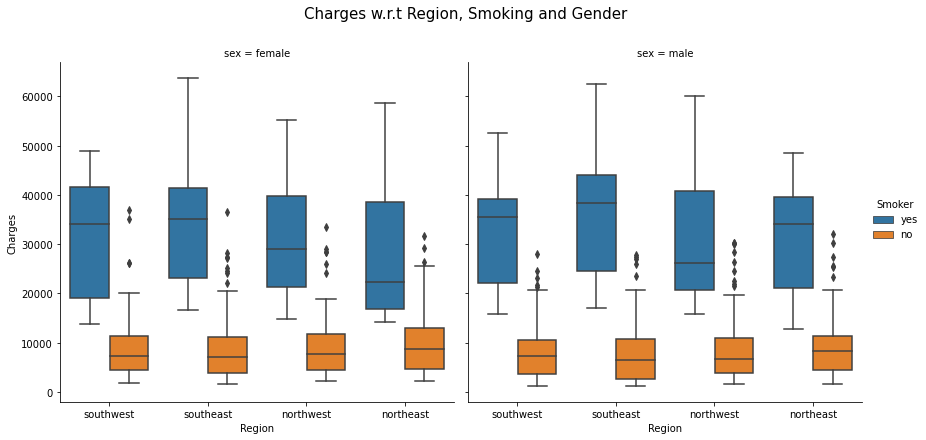

In [15]:
g = sns.catplot(data = df, x='region', y ='charges', hue ='smoker', col ='sex', kind ='box', height=6, aspect = 1)

# Set titles properly
g.fig.suptitle('Charges w.r.t Region, Smoking and Gender', fontsize=15)

# Adjust spacing so title doesn't overlap
g.fig.subplots_adjust(top=0.85)

# Set axis labels
g.set_axis_labels("Region", "Charges")

# Improve legend
g._legend.set_title("Smoker")

plt.show()

1. Smokers pay more health Insurance then non-smokers.
2. If we compare the Region, The average insurnace paid by male smokers is more than female one.
3. The charges for Southeast region is most and northeast is less

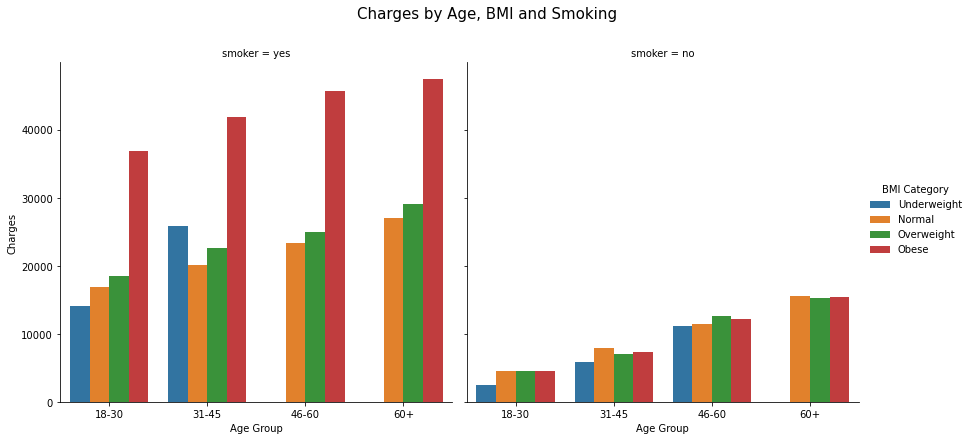

In [16]:
g = sns.catplot(
    data=df,
    x='age_band',
    y='charges',
    hue='bmi_band',
    col='smoker',
    kind='bar',
    height=6,
    aspect=1,
    ci=None
)

g.fig.suptitle('Charges by Age, BMI and Smoking', fontsize=15)
g.fig.subplots_adjust(top=0.85)

g.set_axis_labels("Age Group", "Charges")
g._legend.set_title("BMI Category")

plt.show()

1. It is very much clear that an indivdual who smokes pays more charges.
2. Age also plays very important role in pricing i.e. its directly proportional.
3. Non smoker with more than 60+ and more BMI pays same amount as than of smoker who is in age band 18-30.

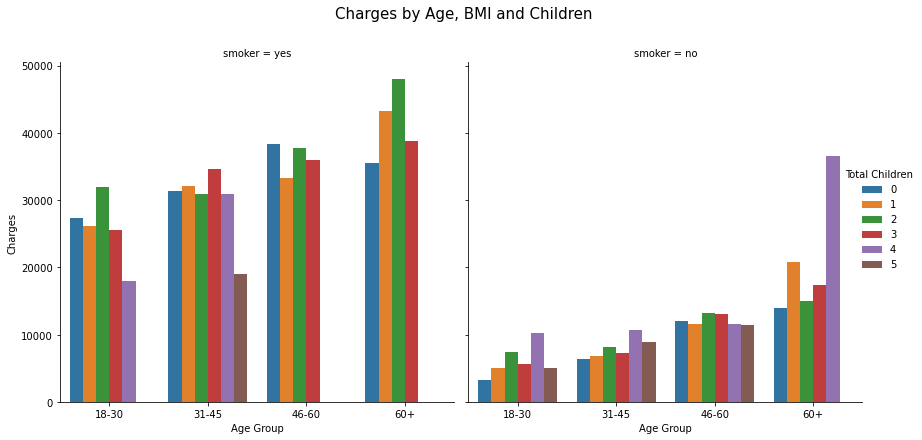

In [17]:
g = sns.catplot(
    data=df,
    x='age_band',
    y='charges',
    hue='children',
    col='smoker',
    kind='bar',
    height=6,
    aspect=1,
    ci=None
)

g.fig.suptitle('Charges by Age, BMI and Children', fontsize=15)
g.fig.subplots_adjust(top=0.85)

g.set_axis_labels("Age Group", "Charges")
g._legend.set_title("Total Children")

plt.show()

1. It appears that total children might not have any effect on Insurnace charges

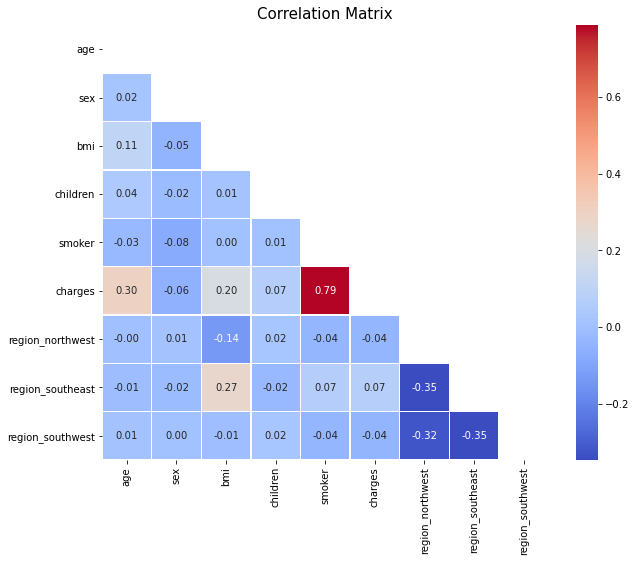

In [18]:
corr = data.corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    linecolor='white',
)

plt.title("Correlation Matrix", fontsize=15)
plt.show()

1. Charges are highly correlated with smoking. BMI and Age are next positively correlated with charges.

### Model Building

In [20]:
#Features and Targets
X = data.drop('charges', axis = 1)
y = data['charges']

In [21]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Linear Regression

In [22]:
# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [23]:
#Predictions
y_pred = model.predict(X_test)

In [24]:
#Evaluation Metrics
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 4181.194473753652
R2 Score: 0.7835929767120723


In [26]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 5796.2846592762735


### Random Forest

In [27]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=11)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=11)

In [31]:
y_pred = rf.predict(X_test)

print('MAE:', mean_absolute_error(y_test, y_pred))
print('R2:', r2_score(y_test, y_pred))

MAE: 2537.9427605880433
R2: 0.8666264368740804


1. Both linear regression and Random Forest provides good results but Random forest provide much better results.
2. The MAE is 2357 which is very good compared to 4181.

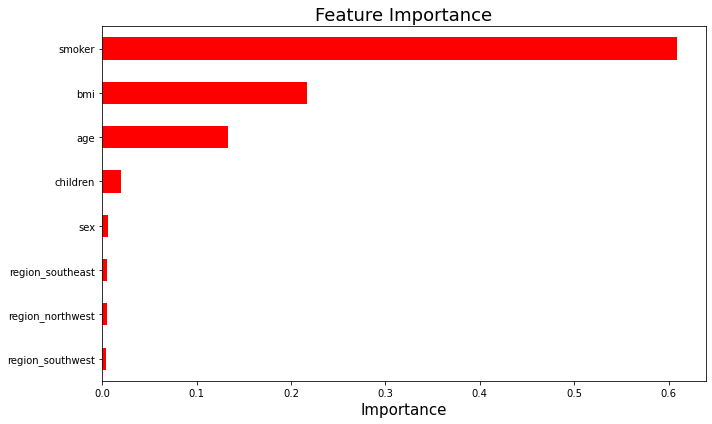

In [33]:
#Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 6), color='r')
plt.title("Feature Importance", fontsize = 18)
plt.xlabel("Importance", fontsize = 15)
plt.tight_layout()
plt.show()

1. As we had seen earlier in correlartion matrix, ist is clear than Smoker, BMI, and Age are imporant factors for pricing.